# Wstęp do Uczenia Maszynowego - Projekt I
## Etap: Drugi Kamień Milowy 
### Autorzy: Krzysztof Osiński, Jakub Miszczak

## Import packages

In [146]:
import pandas as pd
import numpy as np
import sklearn 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
np.random.seed(23)
import zipfile

# Fraud Detection Transactions Dataset - Feature Extraction

In [147]:
zip_path = "fraud-detection-transactions-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open("synthetic_fraud_dataset.csv") as file:
        df = pd.read_csv(file)

In [148]:
df.columns = df.columns.str.replace(" ","_").str.lower()
df1 = df.drop(['transaction_id','user_id'],axis='columns')
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

## Variance Inflation Factor (VIF)
Wartość VIF w okolicach 1 mówi o bardzo małej współliniowości cech.

In [149]:
X = df1.drop('fraud_label', axis='columns')
Y = df1['fraud_label']

from sklearn.preprocessing import MinMaxScaler

scaled_columns = X.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X[scaled_columns] = scaler.fit_transform(X[scaled_columns])
X.describe()

,transaction_amount,timestamp,account_balance,ip_address_flag,previous_fraudulent_activity,daily_transaction_count,avg_transaction_amount_7d,failed_transaction_count_7d,card_age,transaction_distance,risk_score,is_weekend
count,50000.0000,50000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000
mean,0.0847,2023-07-02 12:47:11.063999744,0.5004,0.0502,0.0984,0.4989,0.5006,0.5009,0.5000,0.4998,0.5015,0.2996
min,0.0000,2023-01-01 00:01:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0244,2023-04-02 03:35:30,0.2498,0.0000,0.0000,0.2308,0.2492,0.2500,0.2479,0.2513,0.2539,0.0000
50%,0.0593,2023-07-02 14:00:00,0.5014,0.0000,0.0000,0.4615,0.5022,0.5000,0.5000,0.4981,0.5022,0.0000
75%,0.1183,2023-10-01 07:13:00,0.7499,0.0000,0.0000,0.7692,0.7511,0.7500,0.7521,0.7493,0.7495,1.0000
max,1.0000,2023-12-31 23:50:00,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
std,0.0841,NaN,0.2891,0.2184,0.2979,0.3107,0.2885,0.3536,0.2899,0.2884,0.2878,0.4581


In [150]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    vif_df = pd.DataFrame()
    vif_df['Column'] = df.columns
    vif_df['VIF'] = [variance_inflation_factor(df.values,i) for i in range(df.shape[1])]
    return vif_df

In [151]:
calculate_vif(X[scaled_columns])

,Column,VIF
0,transaction_amount,1.9272
1,account_balance,3.4615
2,ip_address_flag,1.0504
3,previous_fraudulent_activity,1.1036
4,daily_transaction_count,3.1596
5,avg_transaction_amount_7d,3.4722
6,failed_transaction_count_7d,2.7309
7,card_age,3.4294
8,transaction_distance,3.4529
9,risk_score,3.4787


## Weight of Evidence (WOE)

In [152]:
# Funkcja do policzenia WOE i IV dla naszych cech
def calculate_woe_iv(df, feature, target):
    
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_score'] = grouped['good'] / total_good
    grouped['bad_score'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_score']/ grouped['bad_score'])
    grouped['iv'] = (grouped['good_score'] -grouped['bad_score'])*grouped['woe']
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

In [153]:
iv_values = {}

# Liczymy IV 
for feature in X.columns:
    # Jeśli kolumna kategoryczna lub dyskretna to względem kategorii
    if X[feature].dtype == 'object' or feature in ['ip_address_flag', 'previous_fraudulent_activity', 'daily_transaction_count', 
                                                   'failed_transaction_count_7d', 'is_weekend', 'hour', 'weekday', 'is_night',
                                                  'is_large_transaction', 'transaction_bin', 'high_failed_tx_flag', 
                                                   'high_transaction_distance', 'high_sqrt_risk_score', 'low_balance_flag']:
        _, iv = calculate_woe_iv(pd.concat([X, Y],axis=1), feature, 'fraud_label' )
    # Jeśli kolumna numeryczna to dzielimy na biny i liczymy względem binów
    else:
        X_binned = pd.cut(X[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, Y],axis=1), feature, 'fraud_label' )
    iv_values[feature] = iv
    
# Eleganckie zapisanie wyników 
pd.set_option('display.float_format', lambda x: '{:.4f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)

## Information Value (IV)
IV < 0.02  --> brak wartości predykcyjnej

0.3 <= IV < 0.5  --> silna wartość predykcyjna

IV >= 0.5  --> bardzo silna wartość predykcyjna (trzeba uważać na overfitting)

In [154]:
iv_df

,Feature,IV
11,failed_transaction_count_7d,0.5995
16,risk_score,0.4483
9,daily_transaction_count,0.0009
3,account_balance,0.0009
14,transaction_distance,0.0009
13,card_age,0.0005
2,timestamp,0.0004
10,avg_transaction_amount_7d,0.0003
15,authentication_method,0.0003
5,location,0.0002


### Spostrzeżenia
Na tym etapie wartość predykcyjną wykazują jedynie cechy 'failed_transaction_count_7d' i 'risk_score'.

## New Features
Teraz poprzez interakcje między zmiennymi i transformacje zmiennych spróbujmy znaleźć więcej cech.

In [156]:
# Tworzenie nowych cech
X['failed_tx_risk_interaction'] = X['failed_transaction_count_7d'] * X['risk_score']
#X['failed_tx_ratio'] = X['failed_transaction_count_7d'] / X['daily_transaction_count']
X['amount_risk_interaction'] = X['transaction_amount'] * X['risk_score']
X['balance_to_avg_tx_ratio'] = X['account_balance'] / X['avg_transaction_amount_7d']
X['low_balance_flag'] = (X['account_balance'] < X['transaction_amount']).astype(int)

# 7. Detekcja wartości odstających
X['high_transaction_distance'] = (X['transaction_distance'] > X['transaction_distance'].quantile(0.95)).astype(int)
X['high_failed_tx_flag'] = (X['failed_transaction_count_7d'] > 3).astype(int)
X["is_large_transaction"] = (X["transaction_amount"] > X["transaction_amount"].quantile(0.95)).astype(int)
#X["transaction_bin"] = pd.cut(X["transaction_amount"], bins=[0, 50, 200, np.inf], labels=["low", "medium", "high"])

# Transformacje matematyczne
X['log_transaction_amount'] = np.log1p(X['transaction_amount'])
X["sqrt_transaction_amount"] = np.sqrt(X["transaction_amount"])
X['log_account_balance'] = np.log1p(X['account_balance'])
X['sqrt_risk_score'] = np.sqrt(X['risk_score'])
X['sqrt_transaction_distance'] = np.sqrt(X['transaction_distance'])  

X['high_sqrt_risk_score'] = (X['sqrt_risk_score'] > 0.9).astype(int)

# Ekstrakcja cech czasowych
X['hour'] = X['timestamp'].dt.hour
X['weekday'] = X['timestamp'].dt.dayofweek
X['is_night'] = ((X['hour'] >= 0) & (X['hour'] <= 6)).astype(int)

# One-hot encoding dla cech kategorycznych
categorical_features = ['authentication_method', 'device_type', 'card_type', 'transaction_type', 'merchant_category', 'location']
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

scaled_columns = X.select_dtypes(['int64', 'float64']).columns

## Histograms for some new features

In [160]:
features = ['sqrt_risk_score', 'failed_tx_risk_interaction',
            'failed_transaction_count_7d', 'risk_score']

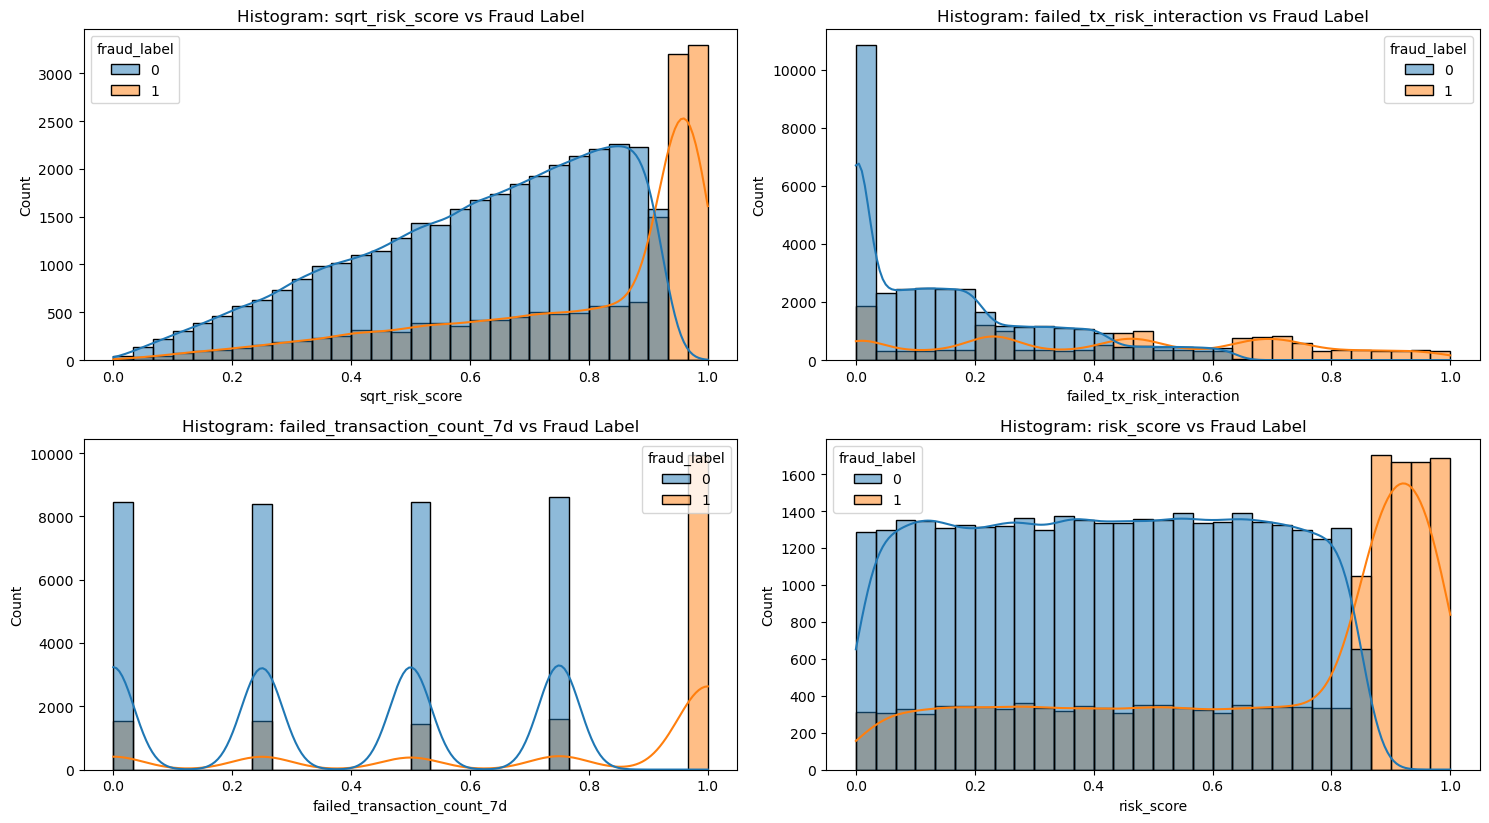

In [161]:
plt.figure(figsize=(15, 12))

# Histogramy
for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=pd.concat([X, Y],axis=1), x=feature, hue='fraud_label', kde=True, bins=30, alpha=0.5)
    plt.title(f'Histogram: {feature} vs Fraud Label')

plt.tight_layout()
plt.show()

## Correlations with target feature

In [162]:
X_numeric = X.select_dtypes(include=['number'])
correlations = X_numeric.corrwith(Y).sort_values(ascending=False)
print(correlations)

high_sqrt_risk_score            0.5358
failed_tx_risk_interaction      0.5297
failed_transaction_count_7d     0.5099
risk_score                      0.3858
sqrt_risk_score                 0.3290
amount_risk_interaction         0.1702
high_transaction_distance       0.0060
hour                            0.0058
low_balance_flag                0.0055
weekday                         0.0053
ip_address_flag                 0.0030
transaction_amount              0.0019
log_transaction_amount          0.0018
sqrt_transaction_amount         0.0012
avg_transaction_amount_7d       0.0007
is_weekend                      0.0001
transaction_distance           -0.0001
is_large_transaction           -0.0005
previous_fraudulent_activity   -0.0007
sqrt_transaction_distance      -0.0013
card_age                       -0.0031
account_balance                -0.0032
log_account_balance            -0.0034
daily_transaction_count        -0.0071
is_night                       -0.0082
balance_to_avg_tx_ratio  

## Random Forest Clasifier: Feature Importances

In [163]:
from sklearn.ensemble import RandomForestClassifier

selected_features = iv_df[iv_df['IV'] >= 0.001]['Feature'].tolist()
X_final = X[selected_features]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_final, Y)

feature_importances = pd.Series(model.feature_importances_, index=X_final.columns).sort_values(ascending=False)
print(feature_importances)

print(feature_importances.sum())

failed_transaction_count_7d   0.5743
risk_score                    0.4257
dtype: float64
1.0


## Lasso: Select From Model

In [164]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

X = X.astype({col: int for col in X.select_dtypes(include=['bool']).columns})
X = X.select_dtypes(exclude=['object', 'datetime'])
X = X.clip(lower=X.quantile(0.01), upper=X.quantile(0.99), axis=1)

# Tworzymy model Lasso (L1)
lasso = Lasso(alpha=0.01)  
lasso.fit(X, Y)

# Wybieramy cechy na podstawie współczynników Lasso
selector = SelectFromModel(lasso, prefit=True)
selected_features = X.columns[selector.get_support()]

# Tworzymy DataFrame z wynikami
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso.coef_})
feature_importance['Selected'] = feature_importance['Feature'].isin(selected_features)

feature_importance = feature_importance.reindex(feature_importance['Coefficient'].abs().sort_values(ascending=False).index)

print(feature_importance)

                           Feature  Coefficient  Selected
6      failed_transaction_count_7d       0.5961      True
23            high_sqrt_risk_score       0.5735      True
35  transaction_type_Bank Transfer       0.0000     False
26                        is_night      -0.0000     False
27       authentication_method_OTP       0.0000     False
28       authentication_method_PIN      -0.0000     False
29  authentication_method_Password       0.0000     False
30              device_type_Mobile      -0.0000     False
31              device_type_Tablet       0.0000     False
32              card_type_Discover       0.0000     False
33            card_type_Mastercard      -0.0000     False
34                  card_type_Visa      -0.0000     False
36         transaction_type_Online      -0.0000     False
24                            hour       0.0000     False
37            transaction_type_POS      -0.0000     False
38   merchant_category_Electronics      -0.0000     False
39     merchan